In [ ]:
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")

library(Biostrings)
library(asreml)

phyloKMat <- read.table(file.path(PHYLOGWAS_ROOT, "output/phyloK_728Poaceae_astral_20250407.txt"))
colnames(phyloKMat) <- rownames(phyloKMat)

# candidate gene discussion:
OG0018915 dPGAM5 

OG0001399 expa5/expa1

In [ ]:
library(Biostrings)

In [1258]:
GOI_DNAaln = readDNAStringSet(file.path(PHYLOGWAS_ROOT, "output/CDSMSAPerOG_gs/OG0001399.gs.l0.fa"))
GOI_AAaln = readAAStringSet(file.path(PHYLOGWAS_ROOT, "output/OG0001399_aaMSA.fa"))

In [1259]:
# convert to matrix (each row = sequence, each column = aligned position)
mat <- as.matrix(GOI_AAaln)

# choose the reference sequence by name or index
ref_name <- grep("ASM1935983v1",names(GOI_AAaln))   # <-- change to your reference ID
# ref_name <- names(aln)[1]  # or take the first sequence

ref_seq <- mat[ref_name, ]
# identify columns where the reference has NO gap
cols_to_keep <- ref_seq != "-"

# subset matrix
mat_filtered <- mat[, cols_to_keep, drop = FALSE]

# convert back to AAStringSet
aln_filtered <- AAStringSet(apply(mat_filtered, 1, paste0, collapse = ""))

# export
writeXStringSet(aln_filtered, file.path(PHYLOGWAS_ROOT, "output/OG0001399_aaMSA.gs.fa"))


In [1260]:
GOI_AAaln = readAAStringSet(file.path(PHYLOGWAS_ROOT, "output/OG0001399_aaMSA.gs.fa"))
GOI_mTab = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/OG0001399.masterDataTable.txt"),data.table = F)

GOI_DNAbin_envPC1Sorted = GOI_DNAaln[GOI_mTab$seqID][order(GOI_mTab$envPC_1)]

In [1261]:
GOI_mTab_filtered = subset(GOI_mTab,queryCov > 0.95)
GOI_AAbin_envPC1Sorted = GOI_AAaln[GOI_mTab_filtered$seqID][order(GOI_mTab_filtered$envPC_1)]

In [1262]:
writeXStringSet(GOI_DNAbin_envPC1Sorted,file.path(PHYLOGWAS_ROOT, "output/OG0001399_CDSMSA_envPC1Sorted.fa"))
writeXStringSet(GOI_AAbin_envPC1Sorted,file.path(PHYLOGWAS_ROOT, "output/OG0001399_aaMSA_envPC1Sorted.fa"))

In [1263]:
AAMSAMat = as.matrix(GOI_AAbin_envPC1Sorted)
consensus = apply(AAMSAMat,2,function(x) names(which.max(table(x))))

In [1264]:
allelesPerSite = apply(AAMSAMat,2,function(x) {
    tmp = table(x)
#     tmp = tmp[!names(tmp)%in%"-"]
    tmp = tmp[tmp>2]
    return(tmp)
})

numAllelePerSite = sapply(allelesPerSite,length)
numAllelePerSite_filtered = numAllelePerSite[numAllelePerSite!=0]

AAMSAMatBinarized = 1-t(apply(AAMSAMat[,numAllelePerSite!=0],1,function(x) as.numeric(x==consensus[numAllelePerSite!=0])))

mafPerSite_filtered = colSums(AAMSAMatBinarized)/nrow(AAMSAMatBinarized)

AAMSAMatBinarized = as.data.frame(AAMSAMatBinarized)

colnames(AAMSAMatBinarized) = paste0("residue",1:ncol(AAMSAMatBinarized))

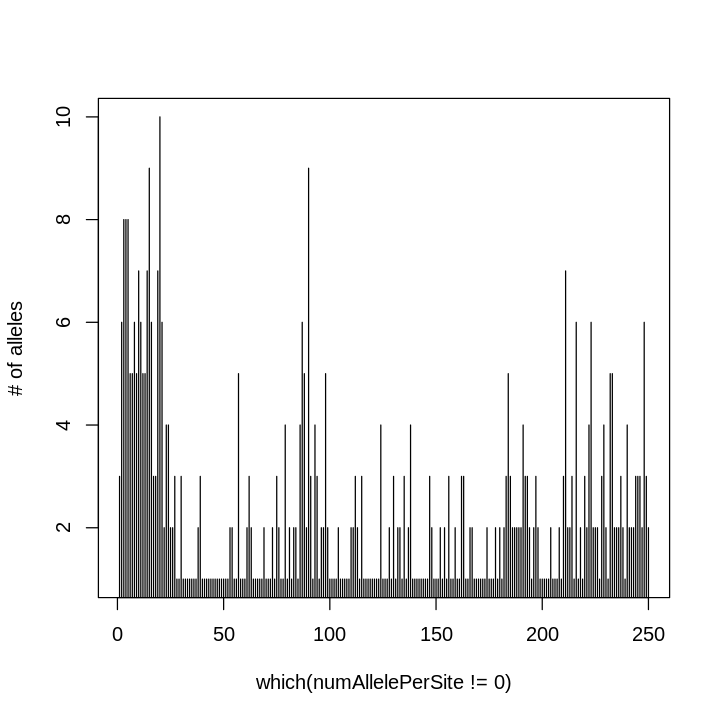

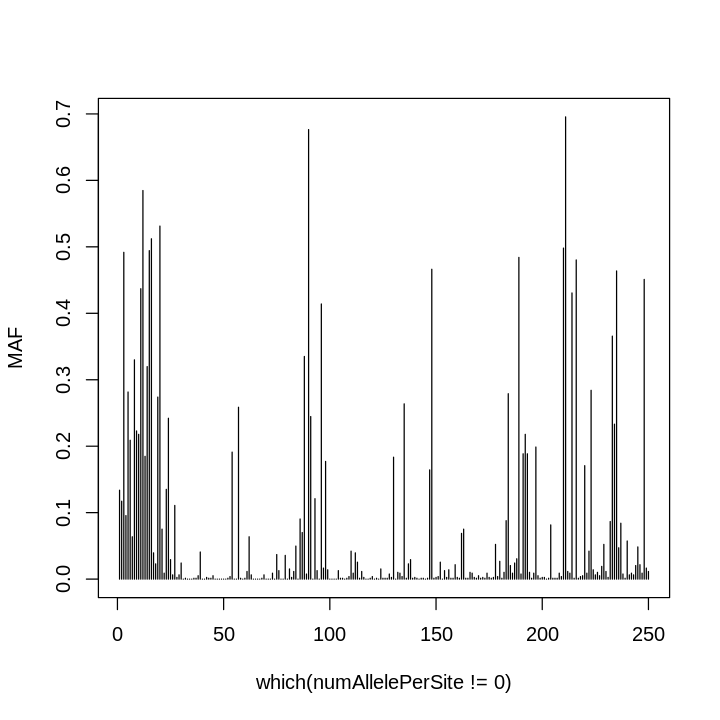

In [1279]:
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "MAF",type = 'h')

In [1265]:
myDat = data.frame(assemblyID = GOI_mTab_filtered$assemblyID,
                   seqID = GOI_mTab_filtered$seqID,
                   tribe = GOI_mTab_filtered$tribe,
                   subtribe = GOI_mTab_filtered$subtribe,
                   envPC1 = GOI_mTab_filtered$envPC_1,
                   queryCov = GOI_mTab_filtered$queryCov,
                   pacbio = GOI_mTab_filtered$pacbio,
                   compdup = GOI_mTab_filtered$compdup)

myDat = myDat[order(myDat$queryCov),]
myDat = cbind(myDat,AAMSAMatBinarized)
myDat$assemblyID = as.factor(myDat$assemblyID)
myDat$pacbio = as.factor(myDat$pacbio)

dim(myDat)

[1] 785 258

In [266]:
library(asreml)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand




Online License checked out Mon Dec  8 11:28:20 2025


Loading ASReml-R version 4.2




In [1266]:
asreml.options(maxit = 30,verbose = F)
pValPerSite = c()
for (i in 1:ncol(AAMSAMatBinarized)){
    if(numAllelePerSite_filtered[i]==1 | mafPerSite_filtered[i]<0.01) {pValPerSite = c(pValPerSite,NA); next}
    FM = as.formula(paste0("envPC1~residue",i,"+queryCov+compdup+pacbio"))
    model_full <- asreml(fixed = FM,
                         random = ~ vm(assemblyID, phyloKMat) , ai.sing = F,data = myDat)
    modelWald <- wald.asreml(model_full)
    pValPerSite = c(pValPerSite,modelWald[2,4])
    names(pValPerSite)[length(pValPerSite)] = i
}


ASReml Version 4.2 15/01/2026 14:50:09
          LogLik        Sigma2     DF     wall
 1     -239.0799     0.6268215    780   14:50:09
 2     -210.4313     0.5695362    780   14:50:10
 3     -165.2528     0.4814149    780   14:50:10
 4     -115.0081     0.3844830    780   14:50:10
 5     -70.96604     0.2946222    780   14:50:10
 6     -43.21704     0.2303356    780   14:50:10
 7     -24.70023     0.1824778    780   14:50:10
 8     -11.26209     0.1458119    780   14:50:10
 9     -1.677111     0.1184379    780   14:50:10
10      4.487186    0.09907393    780   14:50:10
11      8.026632    0.08592474    780   14:50:11
12      9.902088    0.07714127    780   14:50:11
13      10.85617    0.07126169    780   14:50:11
14      11.33632    0.06727716    780   14:50:11
15      11.57955    0.06453278    780   14:50:11
16      11.70452    0.06261159    780   14:50:11
17      11.76976    0.06124704    780   14:50:11
18      11.80433    0.06026605    780   14:50:11
19      11.82288    0.05955391  

In [1267]:
asreml.options(maxit = 30,verbose = F)
pValPerSite_GLM = c()
for (i in 1:ncol(AAMSAMatBinarized)){
    if(numAllelePerSite_filtered[i]==1 | mafPerSite_filtered[i]<0.01) {pValPerSite_GLM = c(pValPerSite_GLM,NA); next}
    FM = as.formula(paste0("envPC1~residue",i,"+queryCov+compdup+pacbio"))
    model_full <- asreml(fixed = FM, ai.sing = F,data = myDat)
    modelWald <- wald.asreml(model_full)
    pValPerSite_GLM = c(pValPerSite_GLM,modelWald[2,4])
    names(pValPerSite_GLM)[length(pValPerSite_GLM)] = i
}


ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.4229     0.8648532    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.3289     0.8647652    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.3487     0.8639087    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.2525     0.8647935    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.7470     0.8650187    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.6772     0.8650384    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.1511     0.8649890    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik

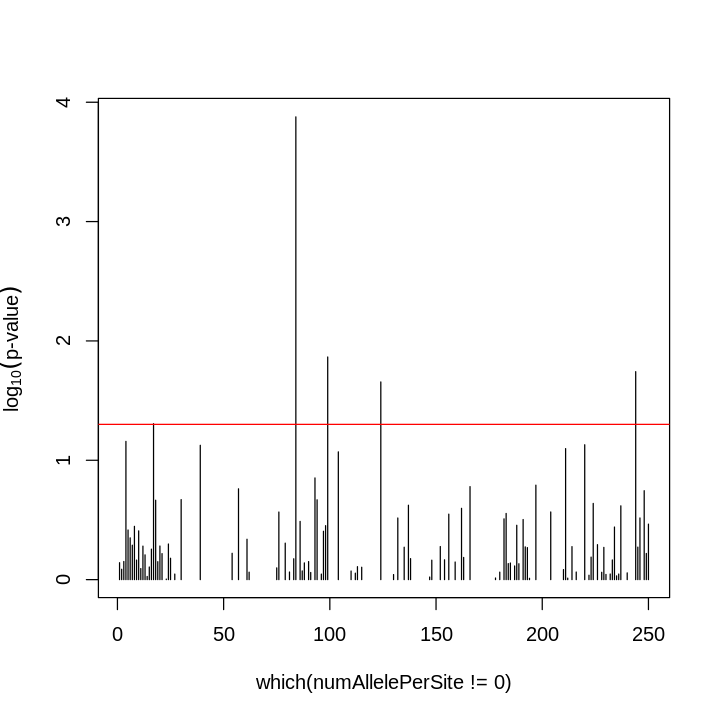

In [1268]:
plot(which(numAllelePerSite!=0),-log10(pValPerSite),ylab = expression(log[10]("p-value")),type = 'h')
abline(h = -log10(0.05),col = "red")

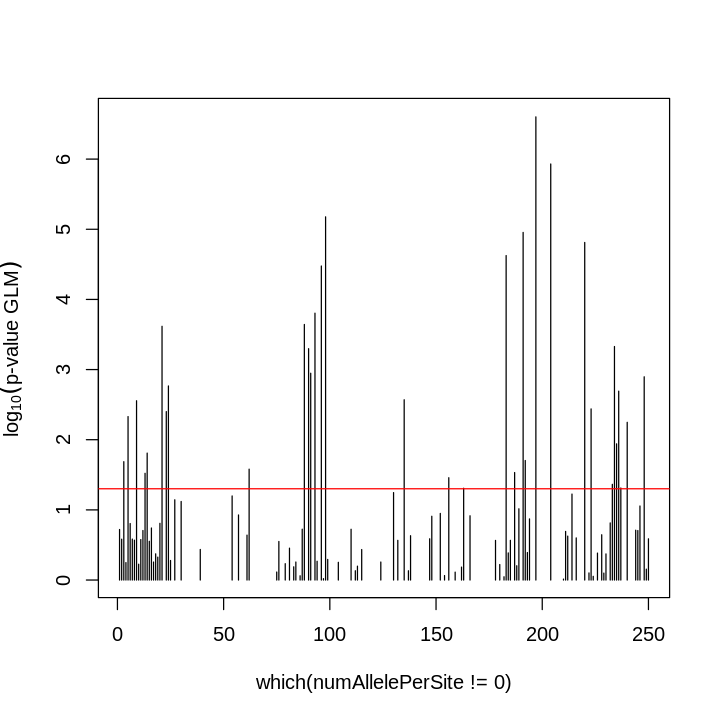

In [1269]:
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),ylab = expression(log[10]("p-value GLM")),type = 'h')
abline(h = -log10(0.05),col = "red")

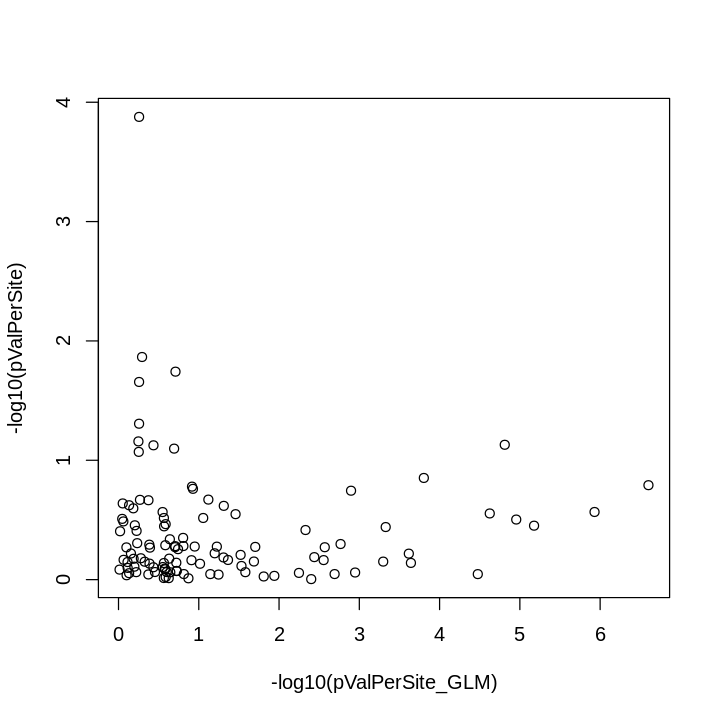

In [1270]:
plot(-log10(pValPerSite_GLM),-log10(pValPerSite))

In [1271]:
sum(pValPerSite_GLM<.05,na.rm = T)

[1] 33

In [1272]:
hapSigSite = apply(AAMSAMat[,na.omit(which(numAllelePerSite!=0)[pValPerSite<=.025])],1,paste,collapse = "")

In [1273]:
which(pValPerSite<=.025)

84  99 124 244 
 84  99 124 244

In [1274]:
hapSigSite

OG0001399:Puccinellia_tenuiflora_refer_1.0:0 
                                           "KVPT" 
     OG0001399:Puccinellia_tenuiflora_refer_1.0:1 
                                           "KVPT" 
     OG0001399:Puccinellia_tenuiflora_refer_1.0:2 
                                           "KIAT" 
                           OG0001399:SRR8208363:0 
                                           "RVPT" 
                           OG0001399:SRR8208363:1 
                                           "RVPT" 
                         OG0001399:ASM1927943v1:0 
                                           "RVPT" 
                         OG0001399:ASM1927943v1:1 
                                           "RVPT" 
                     OG0001399:Poa_pratensis_v1:0 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:1 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:2 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:3 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:4 
                                           "KVPT" 
                           OG0001399:Poa_supina:0 
                                           "KLPT" 
                          OG0001399:AN22TNTL090:0 
                                           "RVPT" 
                                OG0001399:BC100:0 
                                           "RVPT" 
                                OG0001399:BC100:1 
                                           "RVPT" 
                                OG0001399:BC332:0 
                                           "RVPT" 
                                OG0001399:BC332:1 
                                           "RVPT" 
                                OG0001399:BC382:0 
                                           "RVPT" 
                                OG0001399:BC382:1 
                                           "RVPT" 
                                OG0001399:BC404:0 
                                           "RVPT" 
                                OG0001399:BC404:1 
                                           "RVPT" 
                                OG0001399:BC477:0 
                                           "RVPT" 
                                OG0001399:BC477:1 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:0 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:1 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:2 
                                           "RVPT" 
                          OG0001399:SRR15440587:0 
                                           "RVPT" 
                  OG0001399:Aegilops_cylindrica:0 
                                           "RVPT" 
                  OG0001399:Lolium_arundinaceum:0 
                                           "RVPT" 
                    OG0001399:Festuca_brevipila:0 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:1 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:2 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:3 
                                           "KVPT" 
                              OG0001399:Msac_v3:0 
                                           "RVPT" 
                          OG0001399:SRR23019254:0 
                                           "RVPT" 
                         OG0001399:AN21TNTL0156:0 
                                           "RVPT" 
                          OG0001399:AN22TNTL093:0 
                                           "RVPT" 
                         OG0001399:AN21TNTL0302:0 
                                           "RVPT" 
          OG0001399:Ag-CAM1

In [1275]:
myDat$hapSigSite = factor(hapSigSite[myDat$seqID], 
                          level = names(sort(table(hapSigSite[myDat$seqID]))))

In [1276]:
sort(table(hapSigSite[myDat$assemblyID]))


RVAT RVPA RVPI RVST KIQT SIQT KLPT RIPT KIAT RVLT RVP- RVPS KVPT RVPT 
   1    1    1    1    2    2    3    3    4    6    8    9   35  709 

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
hapSigSite,13,79.31803,6.1013870,6.169145,4.327229e-11
Residuals,771,762.53182,0.9890166,NA,NA


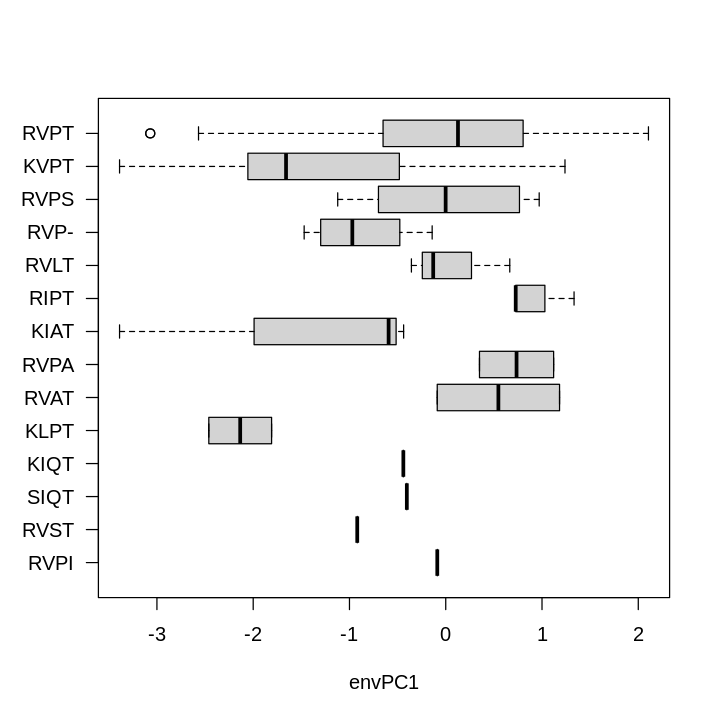

In [1277]:
with(myDat,boxplot(envPC1~hapSigSite,horizontal = T,las =1,ylab = ""))
with(myDat,anova(lm(envPC1~hapSigSite)))

In [1150]:
model_full <- asreml(fixed = envPC1~hapSigSite+queryCov+compdup+pacbio,
#                      random = ~ vm(assemblyID, phyloKMat), 
                     ai.sing = F,data = myDat)
modelWald <- wald.asreml(model_full)
modelWald

ASReml Version 4.2 09/01/2026 10:27:22
          LogLik        Sigma2     DF     wall
 1     -256.6958     0.8279841    572   10:27:22


,Df,Sum of Sq,Wald statistic,Pr(Chisq)
(Intercept),1,13.6223858,16.4524732,4.988506e-05
hapSigSite,25,142.4363657,172.0279054,0.000000e+00
queryCov,1,0.8106148,0.9790222,3.224403e-01
compdup,1,4.2871414,5.1778066,2.287719e-02
pacbio,1,38.2985636,46.2551937,1.038114e-11
residual (MS),NA,0.8279841,NA,NA


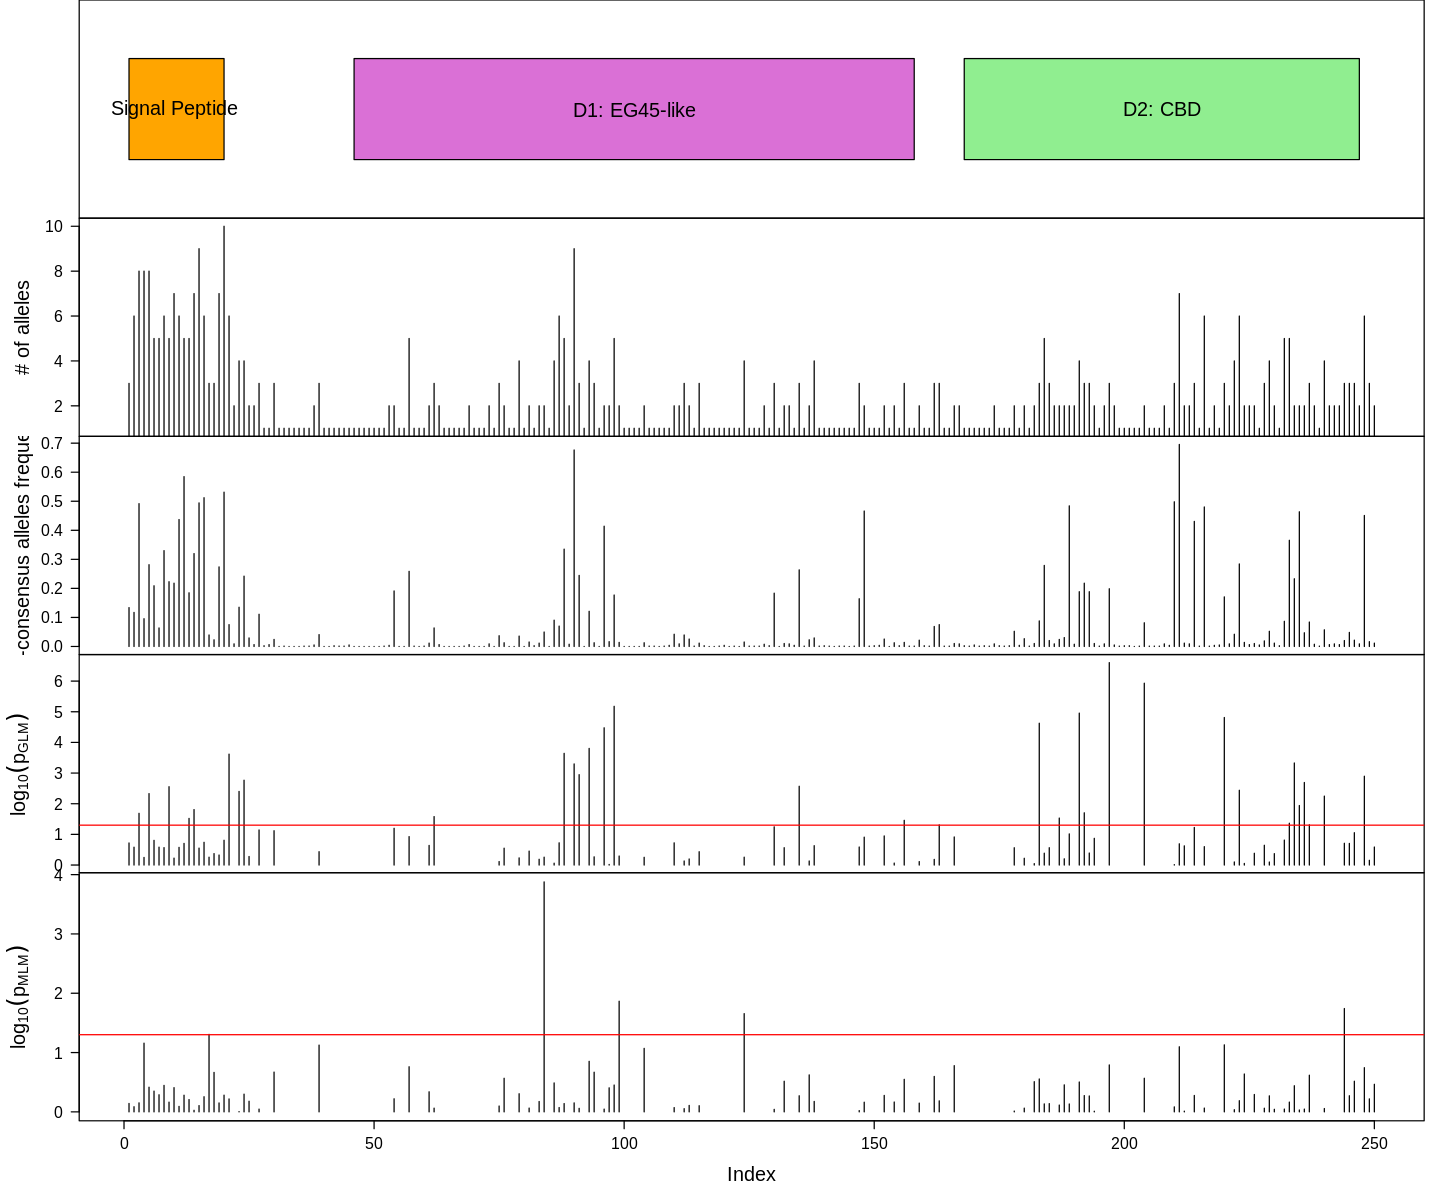

In [1284]:
options(repr.plot.width=12, repr.plot.height=10)
layout(matrix(1:5,ncol = 1),heights = c(1,1,1,1,1.5))
par(mar= c(0,5,0,1),las = 1)
plot(which(numAllelePerSite!=0),rep(1,length(numAllelePerSite_filtered)),type = "n",xaxt = 'n',yaxt ='n',
     xlab = "",ylab = "",ylim = c(0.1,.3))
rect(xleft = 46,xright = 158,ybottom = 0.15,ytop = 0.25,col = "orchid")
text((46+158)/2,.2,labels = "D1: EG45-like",cex = 1.5)
rect(xleft = 168,xright = 247,ybottom = 0.15,ytop = 0.25,col = "lightgreen")
text((168+247)/2,.2,labels = "D2: CBD",cex = 1.5)
rect(xleft = 1,xright = 20,ybottom = 0.15,ytop = 0.25,col = "orange")
text(10,.2,labels = "Signal Peptide",cex = 1.5)

par(mar= c(0,5,0,1),cex.axis = 1.2,cex.lab = 1.5)
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h',xaxt = 'n')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "non-consensus alleles frequency",type = 'h',xaxt ='n')
# abline(h = 0.01,col = "blue")

par(mar= c(0,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),xlab = "Index",ylab = expression(log[10]("p"[GLM])),
     type = 'h',xaxt = 'n')
abline(h = -log10(0.05),col = "red")

par(mar= c(5,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite),xlab = "Index",ylab = expression(log[10]("p"[MLM])),type = 'h')
abline(h = -log10(0.05),col = "red")

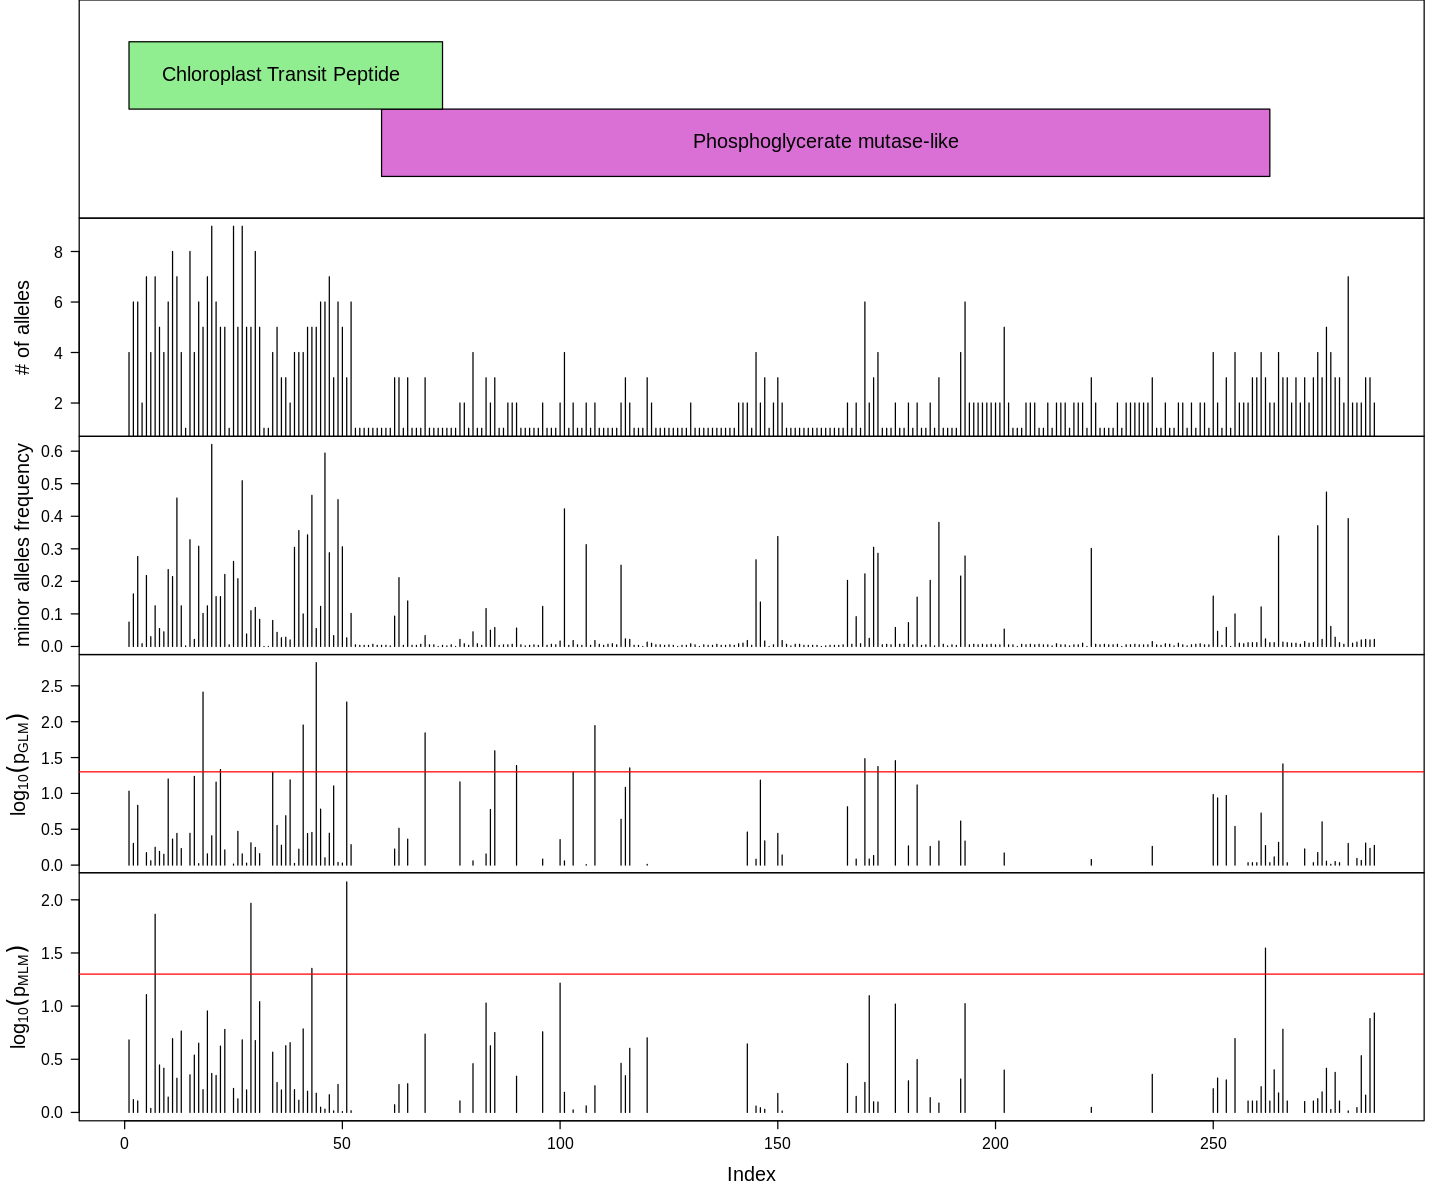

In [1151]:
options(repr.plot.width=12, repr.plot.height=10)
layout(matrix(1:5,ncol = 1),heights = c(1,1,1,1,1.5))
par(mar= c(0,5,0,1),las = 1)
plot(which(numAllelePerSite!=0),rep(1,length(numAllelePerSite_filtered)),type = "n",xaxt = 'n',yaxt ='n',
     xlab = "",ylab = "",ylim = c(0.1,.4))
# rect(xleft = 1,xright = 25,ybottom = 0.2,ytop = 0.3,col = "yellow3")
# text(12.5,.25,labels = "IDR",cex = 1.5)
rect(xleft = 59,xright = 263,ybottom = 0.15,ytop = 0.25,col = "orchid")
text((59+263)/2,.2,labels = "Phosphoglycerate mutase-like",cex = 1.5)

# rect(xleft = 1,xright = 34,ybottom = 0.4,ytop = 0.5,col = "turquoise")
# text(17.5,.45,labels = "Extracelluar")
rect(xleft = 1,xright = 73,ybottom = 0.25,ytop = 0.35,col = "lightgreen")
text(36,.3,labels = "Chloroplast Transit Peptide",cex = 1.5)
# rect(xleft = 58,xright = 287,ybottom = 0.4,ytop = 0.5,col = "salmon")
# text((58+287)/2,.45,labels = "Cytoplasmic")

par(mar= c(0,5,0,1),cex.axis = 1.2,cex.lab = 1.5)
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h',xaxt = 'n')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "minor alleles frequency",type = 'h',xaxt ='n')
# abline(h = 0.01,col = "blue")

par(mar= c(0,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),xlab = "Index",ylab = expression(log[10]("p"[GLM])),
     type = 'h',xaxt = 'n')
abline(h = -log10(0.05),col = "red")

par(mar= c(5,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite),xlab = "Index",ylab = expression(log[10]("p"[MLM])),type = 'h')
abline(h = -log10(0.05),col = "red")

In [1152]:
targetP = read.delim(file.path(PHYLOGWAS_ROOT, "output/OG0018915_TargetP_fullLength.txt"),skip = 1,header = T)

In [1153]:
AAMSAfull = readAAStringSet(file.path(PHYLOGWAS_ROOT, "output/orthofinderProteinMSAs_fullset_20250710/OG0018915.fa"))

In [1154]:
# rownames(targetP) = rownames(AAMSAMat)
rownames(targetP) = names(AAMSAfull)

In [1156]:
table(targetP$Prediction)


  cTP   lTP OTHER    SP 
  679     2   257     5 

In [1157]:
subset(targetP,Prediction=="lTP")

,X..ID,Prediction,OTHER,SP,mTP,cTP,lTP,CS.Position
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
OG0018915:AN21TS34:0,OG0018915_AN21TS34_0,lTP,0.202807,0.134168,0.000264,0.323876,0.338884,CS pos lTP: 62-63. ASA-RG. Pr: 0.5757; CS pos cTP: 36-37. Pr: 0.1139
OG0018915:AN21TSTL0210:0,OG0018915_AN21TSTL0210_0,lTP,0.224710,0.063325,0.003712,0.335638,0.372615,CS pos lTP: 54-55. ASA-RG. Pr: 0.6054; CS pos cTP: 39-40. Pr: 0.1069


In [1158]:
myDat$cTP = targetP[myDat$seqID,6]
# myDat$cTP = as.numeric(strsplit2(targetP[myDat$assemblyID,8],": ")[,3])
# myDat$cTP[is.na(myDat$cTP)] = 0

In [1160]:
model_full <- asreml(fixed = envPC1~cTP+queryCov+compdup+pacbio,
#                      random = ~vm(assemblyID,phyloKMat),
                     ai.sing = F,data = myDat)
modelWald <- wald.asreml(model_full)
modelWald

ASReml Version 4.2 09/01/2026 10:28:27
          LogLik        Sigma2     DF     wall
 1     -188.5269     0.6339410    596   10:28:28
 2     -171.7086     0.5871492    596   10:28:28
 3     -146.6236     0.5149878    596   10:28:28
 4     -117.0817     0.4254150    596   10:28:28
 5     -87.72433     0.3289164    596   10:28:28
 6     -68.44072     0.2567458    596   10:28:28
 7     -55.89134     0.2036008    596   10:28:28
 8     -46.81838     0.1627548    596   10:28:28
 9     -39.94576     0.1311415    596   10:28:29
10     -35.15769     0.1078961    596   10:28:29
11     -32.34902    0.09207853    596   10:28:29
12     -30.97864    0.08201633    596   10:28:29
13     -30.40378    0.07590596    596   10:28:29
14     -30.18729    0.07230504    596   10:28:29
15     -30.11135    0.07022304    596   10:28:29
16     -30.08585    0.06903344    596   10:28:29
17     -30.07751    0.06835856    596   10:28:29
18     -30.07482    0.06797730    596   10:28:30
19     -30.07397    0.06776244  

,Df,Sum of Sq,Wald statistic,Pr(Chisq)
(Intercept),1,0.80917039,11.962629,0.0005427823
cTP,1,0.03335417,0.493102,0.4825468403
queryCov,1,0.12887041,1.905197,0.1674977786
compdup,1,0.53464085,7.904034,0.0049324676
pacbio,1,0.34461237,5.094687,0.0239992421
residual (MS),NA,0.06764152,NA,NA


In [1161]:
with(subset(myDat,tribe=="Triticeae"),anova(lm(envPC1~cTP+queryCov+compdup+pacbio)))
with(subset(myDat,tribe=="Triticeae"),lm(envPC1~cTP+queryCov+compdup+pacbio))

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
cTP,1,1.3208647,1.3208647,11.0243112,0.001666343
queryCov,1,0.0173117,0.0173117,0.1444884,0.705437623
compdup,1,0.1678458,0.1678458,1.4008888,0.242062444
pacbio,1,1.0787910,1.0787910,9.0038954,0.004161454
Residuals,51,6.1105042,0.1198138,NA,NA



Call:
lm(formula = envPC1 ~ cTP + queryCov + compdup + pacbio)

Coefficients:
(Intercept)          cTP     queryCov      compdup   pacbioTRUE  
 -6.9775283   -4.7146449    8.1147160    0.0002734   -0.3028485  


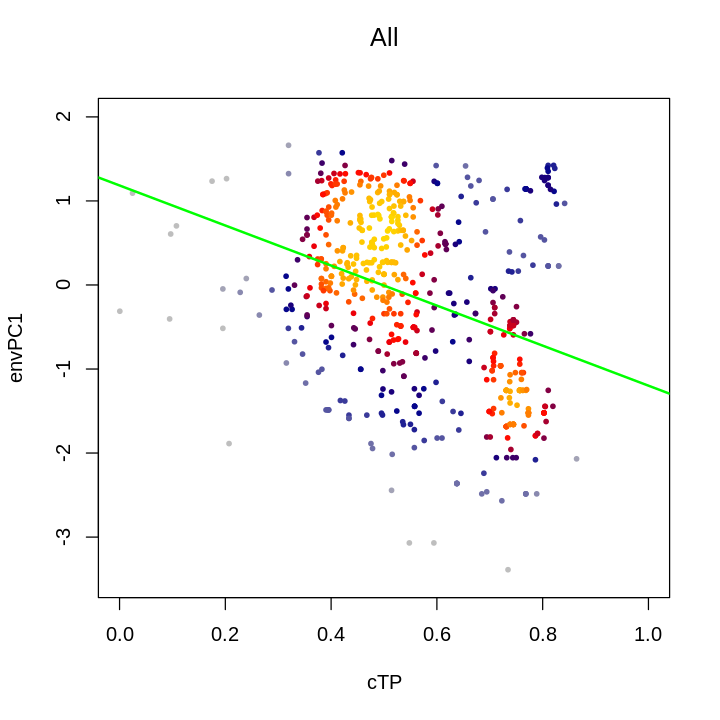

In [1248]:
options(repr.plot.width=6, repr.plot.height=6)
with(myDat,LSD::heatscatter(cTP,envPC1,main = "All",xlim = c(0,1),ylim =c(-3.5,2)))
fm = with(myDat,lm(envPC1~cTP))
abline(a = fm$coefficients[1],b = fm$coefficients[2],lwd =2, col = "green")
